# Sentiment Analysis

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 


## 1. Understanding the Data

In [32]:
# assign column names 
cols = ['id', 'topic', 'sentiment', 'text']
# load the dataset
data = pd.read_csv(
    "twitter.csv",
    names=cols
)
 

In [34]:
# Check the top 5 rows 
data.head()

,id,topic,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [36]:
# check the bottom 5 rows 
data.tail()

,id,topic,sentiment,text
74677,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74678,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74679,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74680,9200,Nvidia,Positive,Just realized between the windows partition of...
74681,9200,Nvidia,Positive,Just like the windows partition of my Mac is l...


In [38]:
# Understand data 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         74682 non-null  int64 
 1   topic      74682 non-null  object
 2   sentiment  74682 non-null  object
 3   text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [40]:
# chech null value counts
data.isnull().sum()

id             0
topic          0
sentiment      0
text         686
dtype: int64

In [46]:
# know the number of rows in dataset
data.shape

(74682, 4)

In [50]:
# Understand the sentiments clearly 
data['sentiment'].value_counts()

sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

In [54]:
# Check for duplicates 
data.duplicated().sum()

np.int64(2700)

In [56]:
# drop the duplicates 
data=data.drop_duplicates()

In [58]:
data.duplicated().sum()

np.int64(0)

## 2. NLP Preprocessing

In [67]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shara\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shara\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\shara\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [94]:
def clean_text(text):
    if isinstance(text, str):
        # lowercase
        text = text.lower()
        
        # remove URLs
        text = re.sub(r'http\S+|www\S+', '', text)
        
        # remove mentions
        text = re.sub(r'@\w+', '', text)
        
        # handle hashtags
        text = re.sub(r'#', '', text)
        
        # remove punctuation
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        
        # tokenize
        tokens = word_tokenize(text)
        
        # remove stopwords (keep negation words)
        tokens = [w for w in tokens if w not in stop_words or w in ['not', 'no']]
        
        # lemmatization
        tokens = [lemmatizer.lemmatize(w) for w in tokens]
        
        return " ".join(tokens)
    
    else:
        return ""

In [96]:
# testing the function
print("BEFORE:", data['text'].iloc[0])
print("AFTER:", clean_text(data['text'].iloc[0]))

BEFORE: im getting on borderlands and i will murder you all ,
AFTER: im getting borderland murder


In [100]:
# comparsion of orginal vs cleaned text
data['clean_text'] = data['text'].apply(clean_text)
data[['text','clean_text']].head()

,text,clean_text
0,im getting on borderlands and i will murder yo...,im getting borderland murder
1,I am coming to the borders and I will kill you...,coming border kill
2,im getting on borderlands and i will kill you ...,im getting borderland kill
3,im coming on borderlands and i will murder you...,im coming borderland murder
4,im getting on borderlands 2 and i will murder ...,im getting borderland murder


## 3. Feature Engineering

In [105]:
# feature engineering ->  converting text to numbers 

# bag of words { counts word frequnecy and ignores the order 
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000) # max_features - Limits vocabulary size

X_bow = bow.fit_transform(data['clean_text'])

In [107]:
X_bow.shape

(71982, 5000)

In [111]:
# tf-idf  { Highlights important words }
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(data['clean_text'])

In [113]:
X_tfidf.shape

(71982, 5000)

### Methods
- `BoW`	treats all words equally
- `TF-IDF`	reduces importance of common words



## 4. Model Building 

In [122]:
x= X_tfidf   # or X_bow
y = data['sentiment']

# train test split data 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

In [126]:
# Model 1 : Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [128]:
# Model 2: Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

In [130]:
# Model 3: Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

## 5. Evaluation

In [134]:
from sklearn.metrics import classification_report, accuracy_score

In [137]:
# Logistic Regression
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.6727095922761687
              precision    recall  f1-score   support

  Irrelevant       0.67      0.50      0.57      2521
    Negative       0.71      0.76      0.74      4277
     Neutral       0.62      0.65      0.63      3594
    Positive       0.68      0.71      0.69      4005

    accuracy                           0.67     14397
   macro avg       0.67      0.65      0.66     14397
weighted avg       0.67      0.67      0.67     14397



In [139]:
# Naive Bayes
print("Naive Bayes")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes
Accuracy: 0.6301312773494478
              precision    recall  f1-score   support

  Irrelevant       0.73      0.34      0.47      2521
    Negative       0.60      0.81      0.69      4277
     Neutral       0.67      0.52      0.59      3594
    Positive       0.61      0.72      0.66      4005

    accuracy                           0.63     14397
   macro avg       0.65      0.60      0.60     14397
weighted avg       0.64      0.63      0.62     14397



In [141]:
# Decision Tree
print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree
Accuracy: 0.7540459818017643
              precision    recall  f1-score   support

  Irrelevant       0.73      0.67      0.70      2521
    Negative       0.80      0.77      0.79      4277
     Neutral       0.76      0.74      0.75      3594
    Positive       0.71      0.80      0.76      4005

    accuracy                           0.75     14397
   macro avg       0.75      0.75      0.75     14397
weighted avg       0.76      0.75      0.75     14397



In [143]:
# store results for easier comparsions 

results = {
    "Model": ["Logistic Regression", "Naive Bayes", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_dt)
    ]
}

In [147]:
# comparsion table 
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy
0,Logistic Regression,0.672710
1,Naive Bayes,0.630131
2,Decision Tree,0.754046


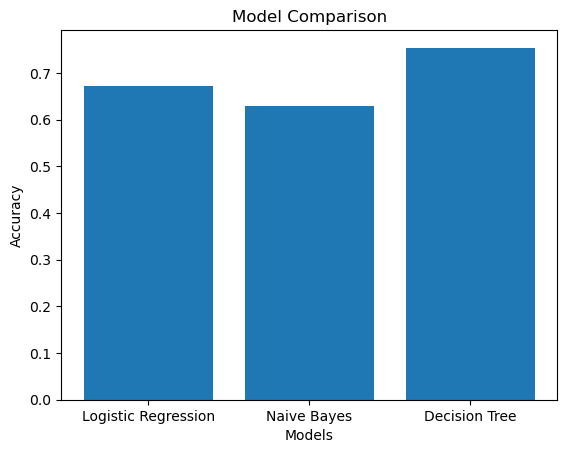

In [151]:
# visual comparsion
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

## 6. Comparison & Insights

### Model Performance Comparison

| Model               | Accuracy |
|--------------------|----------|
| Logistic Regression | 0.67     |
| Naive Bayes         | 0.63     |
| Decision Tree       | 0.75     |

---

### Observations

- **Decision Tree gave the highest accuracy (75%)**, so it performed best among all models.
- **Logistic Regression gave decent performance (67%)** and was balanced across all classes.
- **Naive Bayes had the lowest accuracy (63%)**, especially struggled with some classes like *Irrelevant*.

---

### Class-wise Understanding

- The model performed well on **Negative and Positive** sentiments.
- **Neutral class was slightly harder to predict**.
- **Irrelevant class had lower performance**, especially in Naive Bayes.

---

### Preprocessing Impact

- Removing **URLs, mentions, and punctuation** helped clean the data.
- Converting text to lowercase made it consistent.
- Removing stopwords reduced unnecessary words.
- Lemmatization helped convert words to their base form.

---

### Feature Engineering

- **TF-IDF was used** to convert text into numerical form.
- It helped give more importance to useful words and less importance to common words.

---

### Final Conclusion

- Based on accuracy, **Decision Tree performed the best**.
- However, **Logistic Regression is also a good and stable model for text data**.
- Naive Bayes is simple and fast but gave lower performance in this case.

